# Lab 5 & 6 Data Preparation
### COMM 4259 <br> <i>Foundations of Machine Learning and AI</i>
© Jingjing Li- Ask for permission for using/quoting: jingjing.li@virginia.edu



# Learning Objectives
In this lab we will use Python to clean and process the datasets for customer churn prediction. Specifically, you will learn
- **Clean and normalize data**
    - apply(), lambda, split(), to_datetime()
- **Address missing values**
    - isnull(), isna(), SimpleImputer()
- **Sort, aggregate, merge and concatenate data**
    - sort_values(), groupby(), merge(), concat()
- **Convert non-numerical data into numerical data**
    - get_dummies() 
- **Split the data into training and test sets**
    - train_test_split()
- **Write data into a csv file**
    - to_csv()

# Datasets
We will use two data files. The first one, **Customer.csv**, contains customer demographics. The second, **Transactions.csv**, includes these customers' past purchases.

Below is the data dictionary of these two files. Read it carefully before you start the lab.

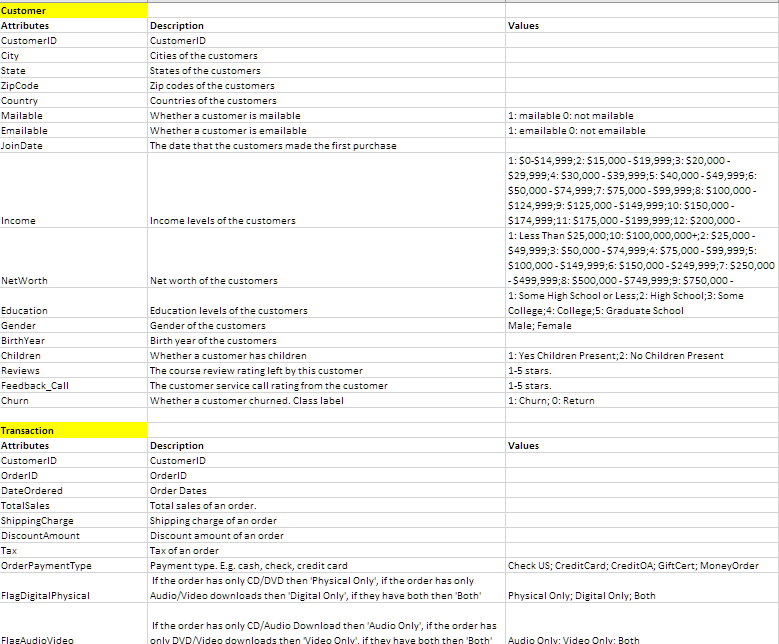

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Run the cells in order.</b> If a cell gives an error after you ran something twice or out of order, click
<b>Restart</b> and then <b>Run All</b> in the notebook toolbar.
</div>

# Import Libraries


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

%precision 4

print(pd.__version__)
print(sns.__version__)

# Part A (Lab 5)

# Customer Data
## Read the csv file and obtain the basic info

In [ ]:
# Read the .csv file and store it as a pandas DataFrame
customer = pd.read_csv("Customer.csv")

# Get the shape
print(customer.shape)

# Get the column types
print(customer.dtypes)

# View the data
customer.head()

## Describe the dataset

In [ ]:
customer.describe()

## Exercise 1: Identify the Attribute Types for the Customer Data
We discussed many data preparation steps in class. Can you devise a data preparation plan for the customer data?

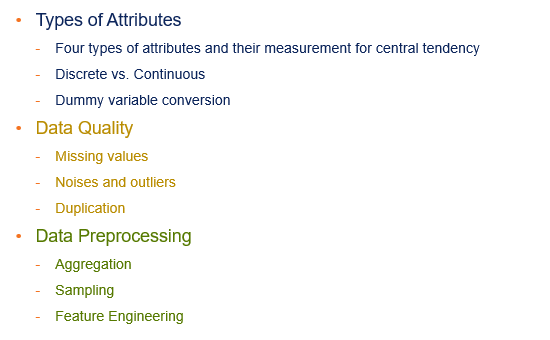

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercise 1: Based on the data dictionary and pandas dataframe, assign each column to Nominal, Ordinal, Interval and Ratio. List the potential data preparation steps (e.g. missing values, cleaning)</b>
</div>

# Clean and Normalize Data

Real-world data is inherently messy.

For instance, the **ZipCode** values are not consistent (mixed with five digits and nine digits). It is a good practice to normalize them into the same length.

Additionally, the **Income, NetWorth, Education and Children** contains textual descriptions repeated throughout the dataset. It is better to use the category number as a shorthand. 

In the following, we will demonstrate how to use the **apply()** and **lambda** function to accomplish the first task and the **split()** function to realize the second.

## Normalize Zipcode length
### apply()

The **apply( )** function applies a value transformation.


<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=P_q0tkYqvSk">video</a> to learn more about the apply() function.
</div>

### lambda function

The apply() function is usually used with **lambda function** for complicated transformations. 

lambda function is a quick way to implement a function. It takes the form of

**lambda argument: expression**

where **argument** is the input variable and **expression** is the returned results for the function.

For instance,
<code> lambda x: x + 5 </code>
will take a variable of x and return the value x + 5.

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=Ob9rY6PQMfI">video</a> to learn more about the lambda function.
</div>

In [ ]:
# Use string slicing to get the first five digits
x = "24416-2110"
x[:5]

In [ ]:
# Need to assign the applied results back to the column
customer["ZipCode"] = customer.ZipCode.apply(lambda x: x[:5])
customer["ZipCode"].head()
customer.head()

## Shorten values for Income, NetWorth, Education and Children
Based on the data dictionary, we know that **Income**, **NetWorth**, and **Education** are ordinal attributes and **Children** is a nominal attribute. We can use a number to represent each category, which happens to be the value before ":".

For instance, for an income value
```"6:  50,000− 74,999"```
the category number is "6".

### split()
The **split( )** function splits a string into a list based on a defined separator. See [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.split.html) for more information

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=bofaC0IckHo&ab_channel=DataSchool">video</a> for a detailed explanation for pandas' string handling (upper, contains, split, replace).
</div>

In [ ]:
# Use the split function to split the income description into a two-element list by colon
customer["Income"].str.split(":")

In [ ]:
# Get the first element after splitting on ":"
# Assign it back to the Income column
customer["Income"] = customer["Income"].str.split(":").str[0]
customer["Income"].head()

## Exercise 2: String handling

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercises: Shorten the value for Networth, Education, and Children</b>
</div>

# Handle Datetime Attribute

### Convert JoinDate to a datetime object

**JoinDate** is a timestamp representing when a customer registers on the website. It was treated as a string when initially read by pandas (shown as `object` in pandas 2 and `str` in pandas 3). Usually, it is a good practice to transform it into a datetime object for time and date-based calculation.


#### to_datetime()

 We can use the **pd.to_datetime()** function to convert a string into a datetime object. This datetime object allows quick extraction of time attributes, such as day, month, year, hour and minutes. See [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html) for detailed description.

In [ ]:
# Initial column type for JoinDate is a string (object)
customer.dtypes

In [ ]:
customer["JoinDate"] = pd.to_datetime(customer["JoinDate"]) # dot notation for column reference
# Now the column types becomes datetime
customer.dtypes

### Create new columns corresponding to year and month of JoinDate

We can use the **apply()** function to extract attributes from the datetime object. A list of attributes could be found  [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Timestamp.html)

In [ ]:
# When creating a new column, have to use bracket notation for column reference on the left hand.
# The right hand side's column reference could be dot or bracket notation
customer["JoinYear"] = customer.JoinDate.apply(lambda x: x.year)
customer["JoinMonth"] = customer.JoinDate.apply(lambda x: x.month)
customer.head(3)

## Exercise 3: Apply() and Datetime Object

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercise: Create two new columns corresponding to JoinDate's day of month and hour of day</b>
    
The day of month of a datetime object is **x.day** and the hour of day is **x.hour**. The new column names are **JoinDay** and **JoinHour**, respectively<br>
</div>

# Address Missing Values

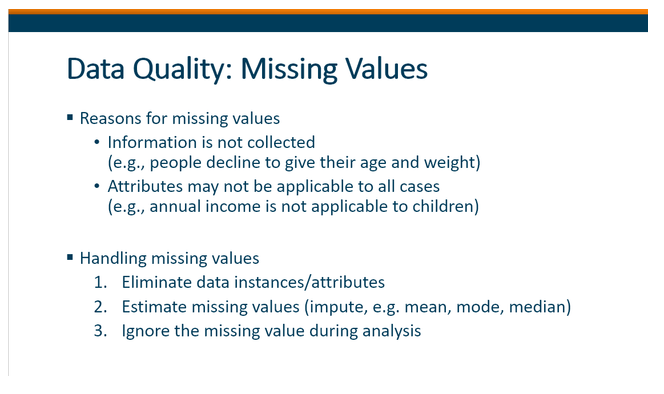

## Find the occurrence of missing values
### isnull() or isna()
We will use the **isnull()** or **isna()** function to find the occurrence of missing values

In [ ]:
# Find the number of missings
customer.isna().sum() # You can replace isnull() with isna()

In [ ]:
# Find the percentage of missings
customer.isnull().mean()

## Remove attributes with more than 80% missing values

In [ ]:
print(customer.shape)
customer.isnull().mean() < 0.8

In [ ]:
# Use the loc function to select the columns whose missing values are less than 80% of the total values
customer = customer.loc[:, customer.isnull().mean() < 0.8]
print(customer.shape)

## Remove rows with more than 50% missing
mean(axis = 1) calculates the mean for the rows

In [ ]:
# Obtain the percentage of missing values for each row
# Sort the percentage from the largest to smallest using sort_values() function
print(customer.shape)
customer.isnull().mean(axis = 1).sort_values(ascending = False) 

In [ ]:
customer = customer.loc[customer.isnull().mean(axis = 1) < 0.5, :]
print(customer.shape)

We have removed the attributes and instances with too many missing values. The remaining missing values
in **BirthYear**, **Gender**, **Income** and **Education** are filled in Part B.

**End of Part A (Lab 5).**

# Part B (Lab 6)

# Sort dataframe
### sort_values()
We can use the **sort_values()** function to sort columns in a dataframe. 

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
For detailed explanation of the sort_values(), watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=zY4doF6xSxY&list=PL5-da3qGB5ICCsgW1MxlZ0Hq8LL5U3u9y&index=7"> video </a>
   </div>

In [ ]:
# sort the dataframe by BirthYear with ascending order
# by default, sort_values() will sort in an ascending order
customer.sort_values("BirthYear").head()

In [ ]:
# sort the dataframe by BirthYear with descending order
customer.sort_values("BirthYear", ascending=False).head()

In [ ]:
# sort dataframe by Income then sort by Education
customer.sort_values(["Income", "Education"]).head()

# Aggregate dataframe
### groupby()
We can use the **groupby( )** to aggregate the data based on central tendency measures (e.g. mean, sum).

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch this <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=qy0fDqoMJx8&list=PL5-da3qGB5ICCsgW1MxlZ0Hq8LL5U3u9y&index=14"> video</a> to learn more about the groupby() function.    
</div>

Roll up the customer data to the state level and obtain the averages for all the numerical variables.

In [ ]:
customer.dtypes

In [ ]:
customer.groupby("State").mean(numeric_only=True)

Let's aggregate the customer data by State and obtain the average for BirthYear.

In [ ]:
customer.groupby(['State']).BirthYear.mean()

## Use groupby to answer the following questions

### Which state, on average, has the oldest customers?

In [ ]:
customer.groupby(['State']).BirthYear.mean().sort_values().head(1)

### Which hour has the most customer registrations?

In [ ]:
customer.groupby('JoinHour').CustomerID.count().sort_values(ascending = False).head(1)

We can use a lineplot to visualize the customer registration by hours.

Note: it is a good practice to create a new dataframe to store the aggregated results. We can use the **reset_index()** to convert the groupby() results into a new dataframe

In [ ]:
hour_count = customer.groupby('JoinHour').CustomerID.count().reset_index()
hour_count

In [ ]:
sns.lineplot(x="JoinHour", y="CustomerID", data = hour_count).set_title(
    "Number of Customers Registered for Each Hour")

## Exercise 4: Find out which month has the most customer registrations.

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercise: Aggregate dataframe</b><br>
    Generate a line chart to visualize the number of customer registered per month.
</div>

In [ ]:
# write your answer here


# Merge Customer data with Transaction data

### merge()
The transaction data includes the historical transactions of a customer. We can join these two datasets together to understand the relationships between demographics and transactions using the merge() function. Since a customer could have multiple transactions, directly joining these two datasets using CustomerID will result in duplicated customer records. Hence, we need to aggregate the transactions at the customer level before joining.

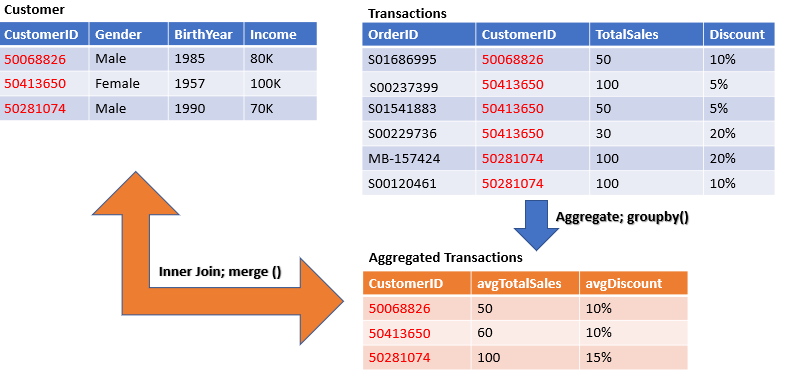

**merge()** joins the different dataframes along columns. See [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html) for more details.



<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
   
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=iYWKfUOtGaw&ab_channel=DataSchool">video</a> to learn more about merge().
</div>


## Read the transaction data and obtain basic info

In [ ]:
# Read the .csv file and store it as a pandas DataFrame
trans = pd.read_csv("Transactions.csv")
trans["DateOrdered"] = pd.to_datetime(trans["DateOrdered"])

print(trans.shape)
trans.head()

## Which orders should we aggregate?
A customer **churns** if they make no purchase for 12 months after their last order. So a customer who
**returns** is, by definition, a customer who ordered again. Look at the number of orders per customer:

In [ ]:
num_orders = trans.groupby("CustomerID").OrderID.count()
pd.crosstab(num_orders.clip(upper=4), customer.set_index("CustomerID").Churn,
            rownames=["number of orders (4 = 4 or more)"])

Almost every customer with one order churned, and almost every customer with two or more orders returned.
The later orders **are** the outcome we want to predict. If we used them as attributes, the model would
look nearly perfect in testing but would be useless in practice: when the company decides whether to keep
marketing to a new customer, those later orders have not happened yet. This is called **target leakage**.

So we only use what is known at the time of prediction: each customer's **first purchase**.

In [ ]:
# Keep the orders placed on each customer's first purchase date
first_date = trans.groupby("CustomerID").DateOrdered.transform("min")
first_orders = trans[trans.DateOrdered == first_date]
print(first_orders.shape)

## Aggregate the first purchase to the customer level
A few customers placed more than one order on their first day, so we still aggregate with mean to get one
row per customer.

In [ ]:
trans_aggr = first_orders[["CustomerID", "TotalSales", "ShippingCharge", "DiscountAmount",
                           "Tax"]].groupby("CustomerID").mean().reset_index()
print(trans_aggr.shape)
trans_aggr.head()

## Inner join customer with aggregated transactions
We found 971 customers' transaction data. Below, we **inner** join the two datasets on CustomerID.

There are many types of joining in pandas:

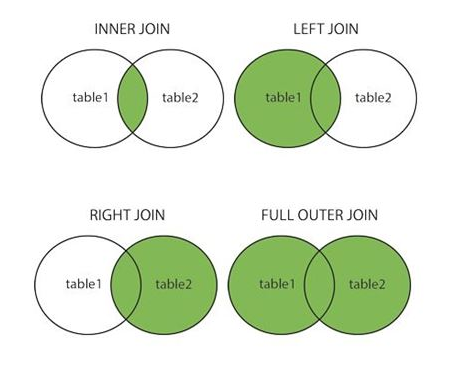

In [ ]:
customer = customer.merge(trans_aggr, on="CustomerID", how="inner")
print(customer.shape)
customer.head()

Alternatively, you can use the following code:

```python
customer = pd.merge(customer, trans_aggr, on = 'CustomerID', how = 'inner')
customer.shape
```

# Convert non-numerical variables into numerical



In [ ]:
customer.dtypes

Based on the column types, we find that **City**, **State**, **ZipCode**, **Country**, **Gender** and
**Children** are nominal variables, and **Income**, **NetWorth**, and **Education** are ordinal variables.

- We can choose to treat **ordinal** variables as numbers or convert them as dummies. Here, we treat them as
  numbers.
- We usually convert **nominal** variables into dummy variables.

## Convert nominal attributes into dummy variables

Among the nominal variables, **City**, **State**, **ZipCode** and **Country** are related to locations and have special data processing steps. Below, we only demonstrate converting **Gender** and **Children** into dummy variables.

### Gender: treat missing as its own category
Gender still has missing values. Instead of filling them with the mode, we treat them as a separate category,
**"Unknown"**. This follows a fixed rule (it does not depend on the other customers), so it is safe to do
before we split the data. It also keeps the information that a customer did not report their gender.

In [ ]:
customer["Gender"] = customer["Gender"].fillna("Unknown")
customer["Gender"].value_counts()

### pd.get_dummies()
**pd.get_dummies( )** converts categorical attributes into dummy variables. See [here](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) for more details.
### pd.concat()
**pd.concat()** concatenates multiple dataframes along the index. See [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.concat.html) for more details.

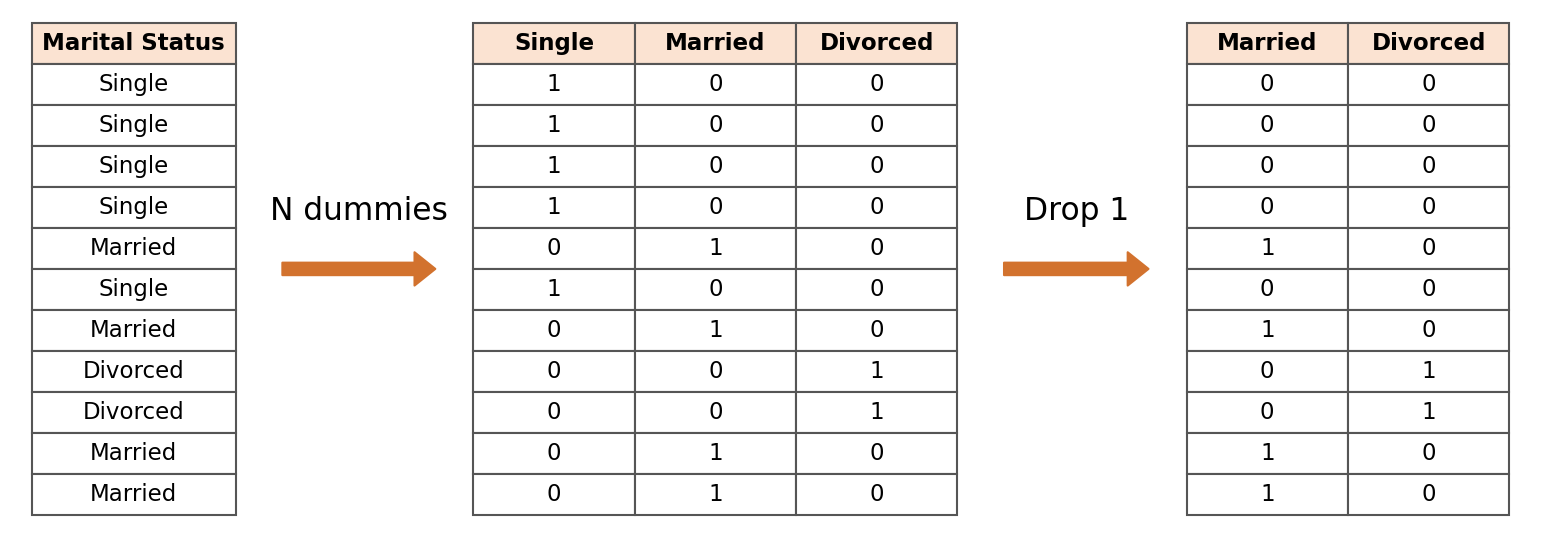

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=0s_1IsROgDc&ab_channel=DataSchool">video</a> to learn more about get_dummies().
    
You can watch the <a style="color:#0645AD; font-weight:600;" href="https://www.youtube.com/watch?v=iYWKfUOtGaw&ab_channel=DataSchool">video</a> to learn more about concat().
</div>



In [ ]:
# prefix adds a prefix to the dummy variable names. drop_first=True drops the first dummy variable.
# dtype=int stores the dummies as 0/1 instead of True/False.
gender_dummy = pd.get_dummies(customer.Gender, prefix="Gender", drop_first=True, dtype=int)
customer = pd.concat([customer, gender_dummy], axis=1)
# if you have executed this cell more than one time, duplicated dummy variables will be created
# We use the following method to remove duplicated columns
customer = customer.loc[:, ~customer.columns.duplicated()]
customer.head()

## Exercise 5: Create a dummy variable for Children

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercise 5: Dummy variable for Children attribute</b><br>
</div>

# Split the data into training and test sets
In Lecture 04, we divided the data into a **training set**, used to build the model, and a **test set**,
used to evaluate it. The test set stands in for **new customers** the model has never seen.

As in Lab 4, we keep 33% of the customers for testing. `stratify` keeps the same churn rate in both sets.

In [ ]:
train, test = train_test_split(customer, test_size=0.33, random_state=1,
                               stratify=customer["Churn"])
train = train.copy()
test = test.copy()

print(train.shape, test.shape)

<div style="background-color:#FFF4CE; color:#5C4200; border:1px solid #E8C86E; border-left:5px solid #D69E00; padding:15px; border-radius:4px;">
<b>Why do we split before filling in missing values?</b><br>
To fill a missing BirthYear with the mean, we first have to <b>compute</b> the mean from the data. That is
learning something from the data, just like training a model.
<ul>
<li>If we compute the mean from <b>all</b> customers, the test customers help decide the values filled into
the training set. The test set is then no longer data the model has never seen, and the test results look
better than they will be on new customers.</li>
<li>So we compute the mean from the <b>training set only</b>, and use that <b>same</b> mean to fill the test
set. A new customer next month would be filled with that same value too.</li>
</ul>
Steps that follow a fixed rule and do not learn anything from the data, such as splitting ZipCode, creating
dummies or filling Gender with "Unknown", are safe to do before the split.
</div>

## Impute missing values
### SimpleImputer()
We use scikit-learn's **SimpleImputer()** to impute missing values. **fit_transform()** learns the value from the training set and fills it in; **transform()** fills the test set with the **same** value.
For interval/ratio variables, we impute with mean or median; For nominal/ordinal variable, we impute with mode or median.

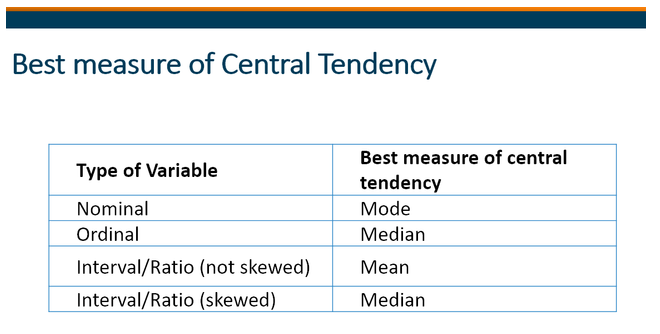

In [ ]:
train.isnull().mean().sort_values(ascending=False).head()

**BirthYear**, **Income** and **Education** still have missing values. BirthYear is an **interval** attribute,
and Income and Education are **ordinal** attributes.

### BirthYear
For interval/ratio variable, we first investigate the skewness and impute with mean or median.

In [ ]:
sns.displot(train.BirthYear.dropna())

It is not significantly skewed, and thus we impute with mean

In [ ]:
mean_imputer = SimpleImputer(strategy="mean")
train[["BirthYear"]] = mean_imputer.fit_transform(train[["BirthYear"]])   # learn the mean from train
test[["BirthYear"]] = mean_imputer.transform(test[["BirthYear"]])         # use the same mean for test

print("Mean BirthYear learned from the training set:", mean_imputer.statistics_)
print(train["BirthYear"].isna().sum(), test["BirthYear"].isna().sum())

### Income and Education
For ordinal variable, we impute with median.

## Exercise 6: Impute missing values for Income and Education

<div style="background-color:#DFF5DC; color:#14532D; border:1px solid #A5D6A7; border-left:5px solid #2E7D32; padding:15px; margin-bottom:20px; border-radius:4px;">
    <b>Exercise 6: Impute missing values for Income and Education</b><br>
    Replace the missing values in these two columns with the median. Follow the BirthYear example above:
    create a <b>SimpleImputer(strategy="median")</b>, use <b>fit_transform()</b> on the training set and
    <b>transform()</b> on the test set. You can impute both columns at once, e.g. train[["Income", "Education"]].<br>
    You need to first convert the string type of Income and Education into numbers by using the following code:
</div>

In [ ]:
train["Income"] = pd.to_numeric(train["Income"], errors="coerce")
train["Education"] = pd.to_numeric(train["Education"], errors="coerce")
test["Income"] = pd.to_numeric(test["Income"], errors="coerce")
test["Education"] = pd.to_numeric(test["Education"], errors="coerce")

## Check if all missing values are addressed

In [ ]:
print(train.isnull().sum().sum())
print(test.isnull().sum().sum())

The sums are zero. Hence, there are no missing values in the training or the test set.

## Convert ordinal attributes into whole numbers
The imputed values are stored as decimals (e.g., 7.0), so we convert the ordinal attributes back into
integers.

In [ ]:
train = train.astype({"Income": "int", "NetWorth": "int", "Education": "int"})
test = test.astype({"Income": "int", "NetWorth": "int", "Education": "int"})
train.dtypes

# Save the cleaned training and test data to csv
### to_csv()
**to_csv( )** saves a DataFrame as a csv file. The setting `index = False` ignores the index column.
You will notice two new csv files in your lab folder.
See [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html) for full
documentation.

If you have finished all the exercises, you should see the shapes (648, 26) and (320, 26).

In [ ]:
train.to_csv("Customer_train.csv", index=False)
test.to_csv("Customer_test.csv", index=False)
print(train.shape, test.shape)

# Lab Exercises (Optional)

## 1. Do women on average spend more than men?
1. Use the cleaned and merged customer dataframe to examine the average order amount (TotalSales) by gender (hint: use groupby()).
2. Describe what you find.

## 2. Which month has the most orders? 
Use the trans dataframe (before aggregation) to find the month that has the most orders. 
1. DateOrdered is already a datetime object. Extract month from it, and then group by month and count the number of OrderID per month.
2. Describe what you find.

## 3. Visualize the average order amount (TotalSales) by Income levels
1. Use the customer dataframe to create a new dataframe with the average total sales per income level.
2. Create a line plot with the x-axis as income (sorted ascendingly) and y-axis as total sales.
3. Describe the patterns of the line plot.

## 4. Preprocess the Transaction data
1. Describe the attribute types of this dataset. 
2. Address the missing values. Please discuss your strategies first and write down your codes later.
3. Convert the order date into a datetime object and create new columns for the day of month, month of year and hour of day.
4. Convert the nominal attributes into dummy variables.
5. Aggregate the first-purchase orders based on the new variables created in 3. and 4. using mean and join with the customer data. 
6. Save the new file as "Customer_cleaned_merged_v2.csv" and print the shape of this dataframe.